In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python3 '/content/drive/MyDrive/file_script.py'

100% 4500/4500 [02:49<00:00, 26.50it/s]


In [ ]:
!python3 '/content/drive/MyDrive/Ayirma.py'

Sınıflar işleniyor: 100% 12/12 [02:20<00:00, 11.69s/it]


In [ ]:
!unzip /content/drive/MyDrive/test.zip -d /content/drive/MyDrive/mulakat_proje/content/split_dataset

In [ ]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
import os
import tensorflow as tf
import numpy as np
import keras_tuner as kt
from keras_tuner.tuners import RandomSearch
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
!pip install tensorflow

In [ ]:
import os
import cv2
import albumentations as A
from xml.dom import minidom
import xml.etree.ElementTree as ET
from tqdm import tqdm

selected_classes = ['star_crack', 'vertical_dislocation', 'fragment', 'corner', 'scratch', 'printing_error']

# Dizinler
base_img_path = '/content/drive/MyDrive/mulakat_proje/content/split_dataset/train/images'
base_xml_path = '/content/drive/MyDrive/mulakat_proje/content/split_dataset/train/labels'

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=25, p=0.5),
    A.RandomScale(scale_limit=0.1, p=0.3),
    A.MotionBlur(blur_limit=3, p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
])

# XML oluşturma
def create_xml(img_name, width, height, class_name, save_path):
    annotation = ET.Element('annotation')
    ET.SubElement(annotation, 'folder').text = 'train'
    ET.SubElement(annotation, 'filename').text = img_name

    source = ET.SubElement(annotation, 'source')
    ET.SubElement(source, 'database').text = 'Unknown'

    size = ET.SubElement(annotation, 'size')
    ET.SubElement(size, 'width').text = str(width)
    ET.SubElement(size, 'height').text = str(height)
    ET.SubElement(size, 'depth').text = '3'

    ET.SubElement(annotation, 'segmented').text = '0'

    obj = ET.SubElement(annotation, 'object')
    ET.SubElement(obj, 'name').text = class_name
    ET.SubElement(obj, 'pose').text = 'Unspecified'
    ET.SubElement(obj, 'truncated').text = '0'
    ET.SubElement(obj, 'difficult').text = '0'

    bndbox = ET.SubElement(obj, 'bndbox')
    ET.SubElement(bndbox, 'xmin').text = '0'
    ET.SubElement(bndbox, 'ymin').text = '0'
    ET.SubElement(bndbox, 'xmax').text = str(width)
    ET.SubElement(bndbox, 'ymax').text = str(height)

    xml_str = ET.tostring(annotation)
    pretty_xml = minidom.parseString(xml_str).toprettyxml(indent="   ")
    with open(save_path, 'w') as f:
        f.write(pretty_xml)

# Augmentasyon işlemi
for class_name in selected_classes:
    img_dir = os.path.join(base_img_path, class_name)
    xml_dir = os.path.join(base_xml_path, class_name)
    os.makedirs(xml_dir, exist_ok=True)

    image_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    if len(image_files) == 0:
        print(f"{class_name} için görsel yok.")
        continue

    total_augmented = 0
    target_count = 100

    print(f"\n  {class_name} sınıfı için başlatıldı")

    while total_augmented < target_count:
        for filename in tqdm(image_files, desc=f"{class_name} augmenting"):
            if total_augmented >= target_count:
                break

            img_path = os.path.join(img_dir, filename)
            image = cv2.imread(img_path)
            if image is None:
                continue

            height, width, _ = image.shape
            augmented = transform(image=image)['image']

            new_img_name = filename.replace('.jpg', f'_aug{total_augmented}.jpg')
            new_img_path = os.path.join(img_dir, new_img_name)
            cv2.imwrite(new_img_path, augmented)

            xml_path = os.path.join(xml_dir, new_img_name.replace('.jpg', '.xml'))
            create_xml(new_img_name, width, height, class_name, xml_path)

            total_augmented += 1

    print(f"  {class_name} için {total_augmented} adet augmentasyon")


In [ ]:
train_path = "/content/drive/MyDrive/mulakat_proje/content/split_dataset/train/images"
val_path = "/content/drive/MyDrive/mulakat_proje/content/split_dataset/val/images"

val_gen = ImageDataGenerator(rescale=1./255)

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(train_path,
                                           target_size=(224, 224),
                                           batch_size=32,
                                           class_mode='categorical')

val_data = val_gen.flow_from_directory(val_path,
                                       target_size=(224, 224),
                                       batch_size=32,
                                       class_mode='categorical')

In [ ]:
def build_model(hp):
    from tensorflow.keras.applications import EfficientNetB0
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras import backend as K
    import tensorflow as tf

    # Focal Loss fonksiyonu
    def categorical_focal_loss(alpha=0.25, gamma=2.0):
      def loss(y_true, y_pred):
          y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1. - K.epsilon())
          cross_entropy = -y_true * tf.math.log(y_pred)
          weight = alpha * tf.math.pow(1 - y_pred, gamma)
          loss = weight * cross_entropy
          return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
      return loss

    # EfficientNetB0 base model
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True  # Fine-tuning

    # Model mimarisi
    model = Sequential()
    model.add(base_model)
    model.add(GlobalAveragePooling2D())

    hp_units = hp.Int('units', min_value=64, max_value=512, step=64)
    model.add(Dense(units=hp_units, activation='relu'))

    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout))

    # Sınıf sayısını otomatik alma
    num_classes = len(train_data.class_indices)
    model.add(Dense(num_classes, activation='softmax'))

    # Compile
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss=categorical_focal_loss(alpha=0.25, gamma=2.0),
        metrics=['accuracy']
    )

    return model

In [ ]:
# Callback'ler
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
print_callback = LambdaCallback(
    on_epoch_end=lambda epoch, logs: print(f"Epoch {epoch+1}: loss={logs['loss']:.4f}, acc={logs['accuracy']:.4f}, val_acc={logs['val_accuracy']:.4f}")
)

# Callbacks listesi
callbacks_list = [early_stop, reduce_lr, print_callback]

Early Stopping

In [ ]:
import tensorflow as tf

def scheduler(epoch, lr):
    if epoch % 5 == 0 and epoch != 0:
        return lr * 0.5
    return lr

class EarlyStoppingManual:
    def __init__(self, patience=5, monitor='val_loss'):
        self.patience = patience
        self.monitor = monitor
        self.best_loss = None
        self.wait = 0

    def stop_training(self, epoch, logs):
        current_loss = logs.get(self.monitor)
        if self.best_loss is None or current_loss < self.best_loss:
            self.best_loss = current_loss
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            print(f"\nEarly stopping at epoch {epoch+1} due to no improvement in {self.monitor}.")
            return True
        return False

def train_with_manual_callbacks(model, train_data, val_data, epochs=30, initial_lr=1e-3):
    early_stop = EarlyStoppingManual(patience=5, monitor='val_loss')

    tf.keras.backend.set_value(model.optimizer.lr, initial_lr)

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        history = model.fit(train_data, epochs=1, validation_data=val_data, verbose=1)

        if early_stop.stop_training(epoch, history.history):
            break

        new_lr = scheduler(epoch, tf.keras.backend.get_value(model.optimizer.lr))
        tf.keras.backend.set_value(model.optimizer.lr, new_lr)
        print(f"Learning Rate after epoch {epoch+1}: {new_lr:.6f}")

Öğrenme Hızı Ayarlama

In [ ]:
import tensorflow as tf

def scheduler(epoch, lr):
    if epoch % 5 == 0 and epoch != 0:  # Her 5. epoch'ta düşür
        return lr * 0.5
    return lr

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)


KERAS TUNER İLE HİPERPARAMETRE ARAMA   

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from keras_tuner.tuners import RandomSearch

#Learning rate scheduler fonksiyonu
def scheduler(epoch, lr):
    if epoch % 5 == 0 and epoch != 0:
        return lr * 0.5
    return lr

#EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# LearningRateScheduler
lr_scheduler = LearningRateScheduler(scheduler, verbose=1)

#Keras Tuner
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='efficientnet_tuning'
)

# Arama
tuner.search(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, lr_scheduler]
)

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]

EĞİTİM

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))


history = best_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.8129 - loss: 0.0561Epoch 1: loss=0.0563, acc=0.8185, val_acc=0.3702
129/129 ━━━━━━━━━━━━━━━━━━━━ 175s 844ms/step - accuracy: 0.8130 - loss: 0.0561 - val_accuracy: 0.3702 - val_loss: 0.3657 - learning_rate: 1.0000e-04
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.8219 - loss: 0.0542Epoch 2: loss=0.0558, acc=0.8275, val_acc=0.4066
129/129 ━━━━━━━━━━━━━━━━━━━━ 74s 571ms/step - accuracy: 0.8220 - loss: 0.0543 - val_accuracy: 0.4066 - val_loss: 0.2727 - learning_rate: 1.0000e-04
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.8299 - loss: 0.0521Epoch 3: loss=0.0494, acc=0.8358, val_acc=0.1558
129/129 ━━━━━━━━━━━━━━━━━━━━ 74s 570ms/step - accuracy: 0.8300 - loss: 0.0521 - val_accuracy: 0.1558 - val_loss: 1.4339 - learning_rate: 1.0000e-04
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.8401 - loss: 0.0490Epoch 4: loss=0.0489, acc=0.8385, val_acc=0.0155
129/129 ━━━

In [ ]:
best_model.save('/content/drive/MyDrive/mulakat_proje/mobilenetv2_08_model.keras')

TEST

In [ ]:
import os
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import pandas as pd

model = load_model('/content/drive/MyDrive/mulakat_proje/mobilenetv2_08_model.keras')

unlabeled_test_path = '/content/drive/MyDrive/mulakat_proje/content/split_dataset/test/JPEGImages'


class_names = list(train_data.class_indices.keys())

results = []

for root, dirs, files in os.walk(unlabeled_test_path):
    for fname in tqdm(files):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(root, fname)
            try:
                img = image.load_img(img_path, target_size=(224, 224))
                img_array = image.img_to_array(img) / 255.0
                img_array = np.expand_dims(img_array, axis=0)

                pred = model.predict(img_array, verbose=0)
                class_index = np.argmax(pred)
                class_label = class_names[class_index]
                confidence = float(np.max(pred))

                results.append((fname, class_label, confidence))
            except Exception as e:
                print(f"Hata: {fname} yüklenemedi. {str(e)}")

df = pd.DataFrame(results, columns=["filename", "predicted_class", "confidence"])
df.to_csv('/content/drive/MyDrive/mulakat_proje/content/split_dataset/test_06_results.csv', index=False)
print("Tahminler kaydedildi.")


SONUÇLAR

Confusion Matrix ve F1-Score

Found 905 images belonging to 12 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step


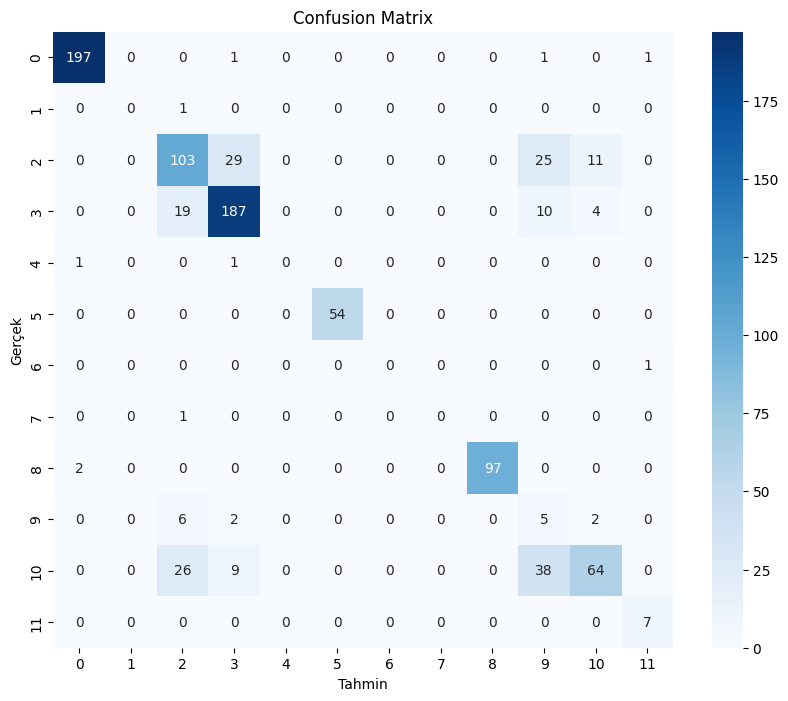

                        precision    recall  f1-score   support

            black_core       0.98      0.98      0.98       200
                corner       0.00      0.00      0.00         1
                 crack       0.66      0.61      0.64       168
                finger       0.82      0.85      0.83       220
              fragment       0.00      0.00      0.00         2
horizontal_dislocation       1.00      1.00      1.00        54
        printing_error       0.00      0.00      0.00         1
               scratch       0.00      0.00      0.00         1
         short_circuit       1.00      0.98      0.99        99
            star_crack       0.06      0.33      0.11        15
            thick_line       0.79      0.47      0.59       137
  vertical_dislocation       0.78      1.00      0.88         7

              accuracy                           0.79       905
             macro avg       0.51      0.52      0.50       905
          weighted avg       0.83     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Tahmin
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.show()

class_labels = list(val_data.class_indices.keys())
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


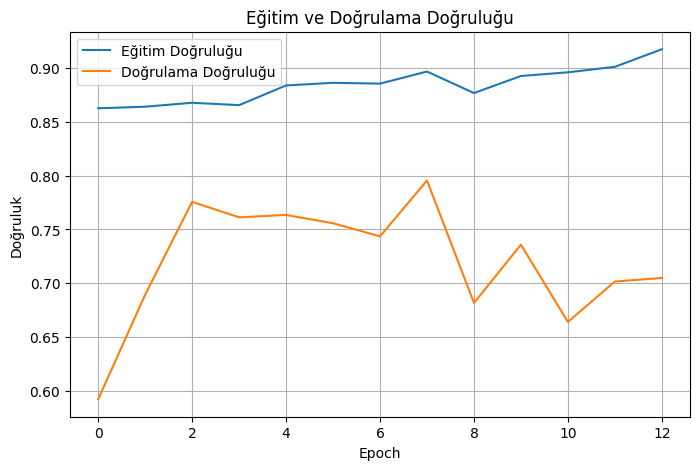

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(acc, label='Eğitim Doğruluğu')
plt.plot(val_acc, label='Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.legend()
plt.grid(True)
plt.show()